# 🧪 TP – Analyse des performances d’étudiants

🎯 **Objectif :** Préparer ce dataset pour un prochain cours qui prédira la note finale d’un étudiant.

### Jeu de données : StudentsPerformance.csv
### Réponder aux questions dans la cellule suivant la question
### Modules autorisés : pandas, mathplotlib, numpy, seaborn, scikit-learn

## 📋 Questions

### 🔹 0. charger le jeu de données et ajout de colonne average_score

a. Charger le jeu de données et puis ajouter une colonne 'average_score' (moyenne des trois notes "math score","reading score","writing score" dans le jeu de données

In [1]:
import pandas as pd

df = pd.read_csv("StudentsPerformance.csv")

df["average_score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3

### 🔹 1. Exploration de base

a. Charger le jeu de données et Afficher les 10 premières lignes du dataset

In [2]:
print(df.head(10))

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   
5  female        group B          associate's degree      standard   
6  female        group B                some college      standard   
7    male        group B                some college  free/reduced   
8    male        group D                 high school  free/reduced   
9  female        group B                 high school  free/reduced   

  test preparation course  math score  reading score  writing score  \
0                    none          72             72             74   
1               completed          69             90             88   
2               

b. Combien d’étudiants ont participé à l’étude ?

In [3]:
print("Nombre d'étudiants :", len(df))

Nombre d'étudiants : 1000


c. Existe-t-il des doublons (étudiants) ?

In [4]:
nb_doublons = df.duplicated().sum()

print("Nombre de doublons :", nb_doublons)

Nombre de doublons : 0


d. Donner les statistiques de base des scores (max, min, moyenne, mediane)

In [5]:
scores = ["math score", "reading score", "writing score"]

stats = pd.DataFrame({
    "min": df[scores].min(),
    "max": df[scores].max(),
    "moyenne": df[scores].mean(),
    "mediane": df[scores].median()
})

print(stats)

               min  max  moyenne  mediane
math score       0  100   66.089     66.0
reading score   17  100   69.169     70.0
writing score   10  100   68.054     69.0


### 🔹 2. Détection de valeurs manquantes ou incohérentes

a. Nombre de valeurs manquantes par cellule?

In [6]:
missing_values = df.isnull().sum()

print(missing_values)

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
average_score                  0
dtype: int64


b. Combien d'étudiants ont un score moyen < 40 ?

In [7]:
df["average_score"] = df[["math score", "reading score", "writing score"]].mean(axis=1)

nb = (df["average_score"] < 40).sum()

print("Nombre d'étudiants avec score moyen < 40 :", nb)

Nombre d'étudiants avec score moyen < 40 : 30


c. Valeurs aberrantes pour le score moyen ? (utiliser visualisation et la Méthode de l’écart interquartile [à lire])

In [8]:
df["average_score"] = df[["math score", "reading score", "writing score"]].mean(axis=1)

Q1 = df["average_score"].quantile(0.25)
Q3 = df["average_score"].quantile(0.75)
IQR = Q3 - Q1

borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

outliers = df[(df["average_score"] < borne_inf) | (df["average_score"] > borne_sup)]

print("Nombre de valeurs aberrantes :", len(outliers))
print(outliers[["average_score"]])

Nombre de valeurs aberrantes : 6
     average_score
17       26.000000
59        9.000000
76       26.000000
327      23.333333
596      23.000000
980      18.333333


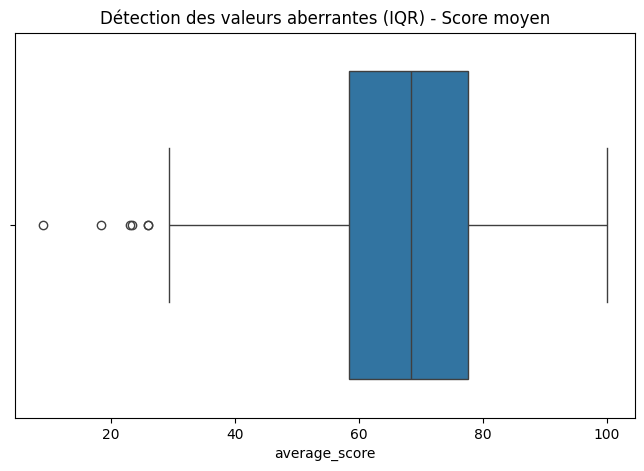

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=df["average_score"])

plt.title("Détection des valeurs aberrantes (IQR) - Score moyen")
plt.show()

### 🔹 3. Visualisation des données

a. Histogramme des notes moyennes

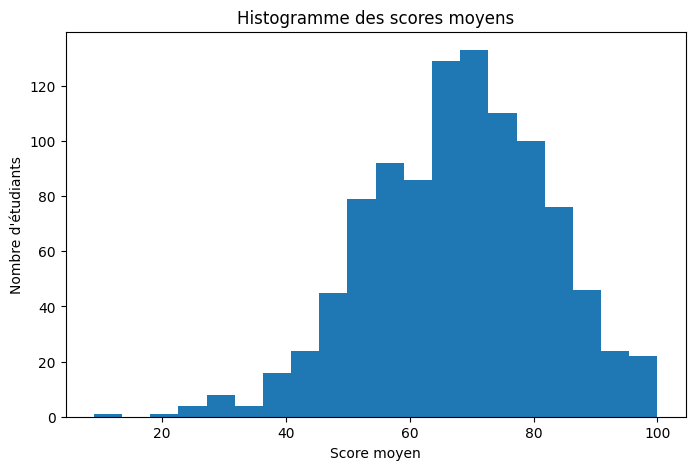

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df["average_score"], bins=20)

plt.title("Histogramme des scores moyens")
plt.xlabel("Score moyen")
plt.ylabel("Nombre d'étudiants")

plt.show()

b. Peut-on voir sur cet histogramme des valeurs abérrantes?

oui... il y a une qui est isolé

c. Faire une boxplot des moyennes par genre.

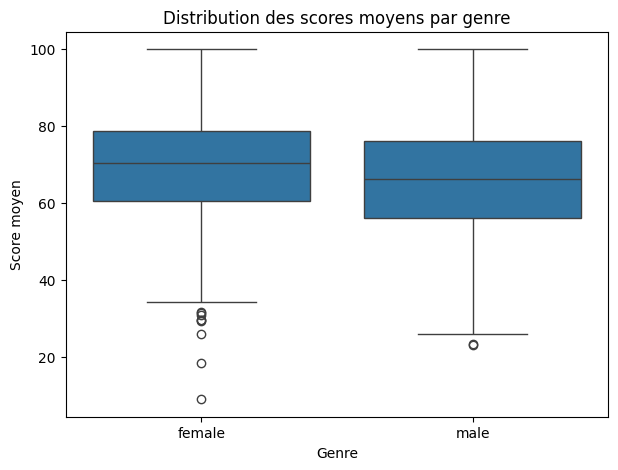

In [11]:
plt.figure(figsize=(7,5))
sns.boxplot(x="gender", y="average_score", data=df)

plt.title("Distribution des scores moyens par genre")
plt.xlabel("Genre")
plt.ylabel("Score moyen")

plt.show()

d. Est-ce qu'il y a une différence nette des moyennes de genre sur ce boxplot? 

oui

e. Barplot moyenne par niveau d'éducation des parents? Peut-on avoir des conclusions sur cette variable?

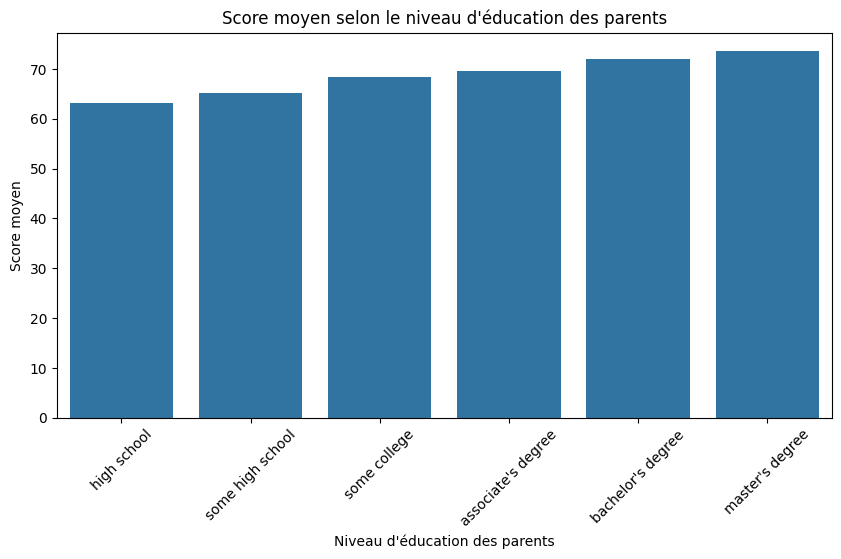

In [12]:
edu_means = df.groupby("parental level of education")["average_score"].mean().sort_values()

plt.figure(figsize=(10,5))
sns.barplot(x=edu_means.index, y=edu_means.values)

plt.title("Score moyen selon le niveau d'éducation des parents")
plt.xlabel("Niveau d'éducation des parents")
plt.ylabel("Score moyen")

plt.xticks(rotation=45)
plt.show()

en moyenne mitovitovy daoly iany ny isany zareo par niveau du coup tsitako ze ambara 

d. Faire le Heatmap de corrélation. Quelle est la variable la plus correlée avec la note moyenne?

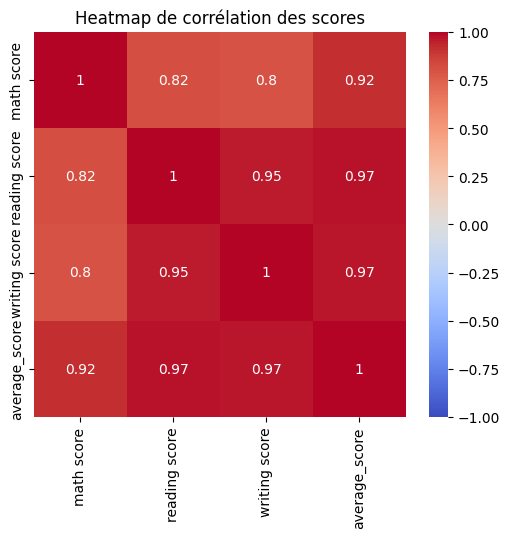

In [13]:
corr = df[["math score", "reading score", "writing score", "average_score"]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Heatmap de corrélation des scores")
plt.show()

reading et writing score

### 🔹 4. Nettoyage des données

a. Imputation des NaN (remplacer les NaN par la moyenne de la variable correspondante)

In [14]:
df_imputed = df.fillna(df.mean(numeric_only=True))

b. Suppression des colonnes inutiles ( Identifiez les colonnes qui sont redondantes, constantes ou sans valeur explicative[aucune corrélation] )

In [15]:
df = df.drop(columns=["math score", "reading score", "writing score"])

c. Sélection des colonnes utiles

In [16]:
useful_columns = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course",
    "average_score"
]

df = df[useful_columns]

### 🔹 5. Encodage

a. Encodage de `gender` ( rendre en numérqieu de façon catégorielle )

In [17]:
# Encodage de gender
df["gender"] = df["gender"].map({
    "female": 0,
    "male": 1
})

b. Encodage one-hot de `parental_level_of_education`

In [18]:
df = pd.get_dummies(
    df,
    columns=["parental level of education"],
    prefix="parent_edu"
)

print(df.head())

   gender race/ethnicity         lunch test preparation course  average_score  \
0       0        group B      standard                    none      72.666667   
1       0        group C      standard               completed      82.333333   
2       0        group B      standard                    none      92.666667   
3       1        group A  free/reduced                    none      49.333333   
4       1        group C      standard                    none      76.333333   

   parent_edu_associate's degree  parent_edu_bachelor's degree  \
0                          False                          True   
1                          False                         False   
2                          False                         False   
3                           True                         False   
4                          False                         False   

   parent_edu_high school  parent_edu_master's degree  \
0                   False                       False   
1 

c. Est-il utilise pour l'encodage de `parental_level_of_education` de faire un Regroupement des modalités ? 

### 🔹 6. Préparation finale

a. Créer X (features) et y (cible: average_score)

In [19]:
y = df["average_score"]
X = df.drop(columns=["average_score"])

b. Vérifier que X est bien numérique

In [24]:
X.dtypes

gender                               int64
parent_edu_associate's degree        int64
parent_edu_bachelor's degree         int64
parent_edu_high school               int64
parent_edu_master's degree           int64
parent_edu_some college              int64
parent_edu_some high school          int64
race/ethnicity_group A               int64
race/ethnicity_group B               int64
race/ethnicity_group C               int64
race/ethnicity_group D               int64
race/ethnicity_group E               int64
lunch_free/reduced                   int64
lunch_standard                       int64
test preparation course_completed    int64
test preparation course_none         int64
dtype: object

In [21]:
X = pd.get_dummies(X, columns=["race/ethnicity", "lunch", "test preparation course"])

In [23]:
bool_cols = X.select_dtypes(include=["bool"]).columns
X[bool_cols] = X[bool_cols].astype(int)

c. Sauvegarder X et y

In [25]:
X.to_csv("X.csv", index=False)
y.to_csv("y.csv", index=False)

## 💡 Bonus

In [ ]:
# Fonction preprocess_students_data(df)

a. Visualisation libre d'une tendance surprenante